In [1]:
import scanpy as sc
import scvelo as scv

In [2]:
adata = sc.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")

Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs fo

    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/24 cores)


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


  0%|          | 0/500 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


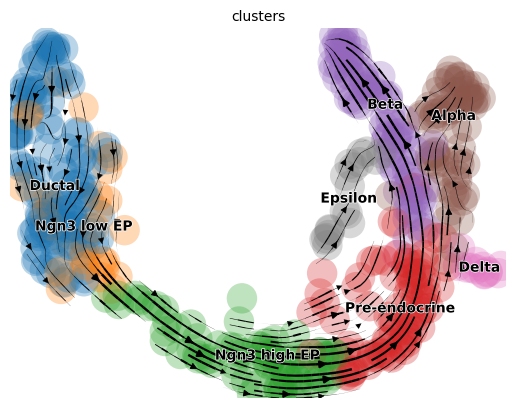

AnnData object with n_obs × n_vars = 500 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition'
    var: 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'cfe', 'log1p', 'neighbors', 'velocity_params', 'velocity_graph', 'velocity_graph_neg', 'clusters_colors'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    layers: 'count', 'expression', 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity', 'variance_velocity'
    obsp: 'distances', 'connectivities'

In [3]:
scv.pp.filter_and_normalize(adata, n_top_genes=2000)
scv.pp.moments(adata)

scv.tl.velocity(adata)
scv.tl.velocity_graph(adata)
scv.tl.velocity_embedding(adata)

scv.pl.velocity_embedding_stream(adata)
adata

计算源簇中细胞速率与里程碑速率的一致性

In [4]:
import numpy as np
import pandas as pd


self = adata

cluster = "clusters"
basis = "X_umap"

velocity_basis = f"velocity_{basis[2:]}"
velocity_embedding = adata.obsm[velocity_basis]

# compute milestone embedding based clustered cell embedding 
X_emb = pd.DataFrame(adata.obsm[basis], index=adata.obs.index)
milestone_emb = adata.obs.groupby(cluster).apply(lambda x: X_emb.loc[x.index].mean(axis=0))
milestone_emb.index = list(adata.obs[cluster].cat.categories)

# NOTE: new strategy to compute milestone network
threshold = 0.6
cluster_list = adata.obs[cluster].cat.categories.to_list()
cluster_connection_df = pd.DataFrame(0.0, index=cluster_list, columns=cluster_list)
for source_cluster in cluster_list:
    source_cell_velocity = velocity_embedding[np.where(self.obs[cluster] == source_cluster)[0]]
    source_cell_velocity = source_cell_velocity / (np.linalg.norm(source_cell_velocity, axis=1, keepdims=True) + 1e-6) # TODO: optimize
    for target_cluster in cluster_list:
        if source_cluster == target_cluster:
            continue
        milestone_emb_source = milestone_emb.loc[source_cluster].values
        milestone_emb_target = milestone_emb.loc[target_cluster].values
        cluster_velocity = milestone_emb_target - milestone_emb_source
        cluster_velocity = cluster_velocity / (np.linalg.norm(cluster_velocity) + 1e-6)
        # cosine similarity between each cell's velocity and the inter-cluster direction
        # normalized vector dot calculation is equal to cosin similarity calculation.
        cosine_sims = source_cell_velocity @ cluster_velocity
        # TODO: weighted
        cluster_connection_df.loc[source_cluster, target_cluster] = cosine_sims.mean()
milestone_network = cluster_connection_df.stack().reset_index()
milestone_network.columns = ["from", "to", "score"]
milestone_network = milestone_network[milestone_network["score"] > threshold].copy()
milestone_network["length"] = 1.0
milestone_network["directed"] = True

print(milestone_network)
cluster_connection_df.style.background_gradient()

/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


             from             to     score  length  directed
1          Ductal    Ngn3 low EP  0.608985     1.0      True
19   Ngn3 high EP  Pre-endocrine  0.896080     1.0      True
21   Ngn3 high EP          Alpha  0.652812     1.0      True
22   Ngn3 high EP          Delta  0.879023     1.0      True
28  Pre-endocrine           Beta  0.611772     1.0      True
29  Pre-endocrine          Alpha  0.862979     1.0      True
30  Pre-endocrine          Delta  0.790538     1.0      True
53          Delta          Alpha  0.840686     1.0      True
60        Epsilon           Beta  0.927248     1.0      True
61        Epsilon          Alpha  0.883291     1.0      True


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


,Ductal,Ngn3 low EP,Ngn3 high EP,Pre-endocrine,Beta,Alpha,Delta,Epsilon
Ductal,0.000000,0.608985,0.400896,0.178133,-0.129762,-0.091889,0.086004,0.007711
Ngn3 low EP,-0.762298,0.000000,0.562020,0.344300,-0.003399,0.055232,0.255562,0.141734
Ngn3 high EP,-0.887567,-0.911802,0.000000,0.896080,0.451949,0.652812,0.879023,0.501244
Pre-endocrine,-0.388288,-0.445446,-0.736222,0.000000,0.611772,0.862979,0.790538,0.293345
Beta,0.510484,0.426720,-0.195949,-0.757385,0.000000,-0.698416,-0.923263,-0.316031
Alpha,-0.216985,-0.274042,-0.567745,-0.708849,-0.059098,0.000000,-0.646079,-0.434030
Delta,-0.145681,-0.209756,-0.541184,-0.598770,0.499810,0.840686,0.000000,0.068407
Epsilon,-0.622737,-0.696853,-0.955589,-0.275578,0.927248,0.883291,0.362716,0.000000


计算投影到边上的细胞与簇中细胞的一致性, 一个细胞会投影到多条边上

In [5]:
from cafe.util import project_to_segments

# NOTE: new strategy to compute milestone network
threshold = 0.6
cluster_list = adata.obs[cluster].cat.categories.to_list()
cluster_connection_df = pd.DataFrame(0.0, index=cluster_list, columns=cluster_list)
for source_cluster in cluster_list:
    for target_cluster in cluster_list:
        if source_cluster == target_cluster:
            continue
        milestone_emb_source = milestone_emb.loc[source_cluster].values
        milestone_emb_target = milestone_emb.loc[target_cluster].values
        # milestone cluster velocity
        cluster_velocity = milestone_emb_target - milestone_emb_source
        cluster_velocity = cluster_velocity / (np.linalg.norm(cluster_velocity) + 1e-6)
        # extract cell projected to the segment between source and target cluster
        proj = project_to_segments(X_emb, milestone_emb_source.reshape(1, -1), milestone_emb_target.reshape(1, -1))
        progression = proj["progression"]
        cell_velocity = velocity_embedding[np.where((progression != 0) & (progression != 1))]
        cell_velocity = cell_velocity / (np.linalg.norm(cell_velocity, axis=1, keepdims=True) + 1e-6)  # TODO: optimize
        # cosine similarity between each cell's velocity and the inter-cluster direction
        cosine_sims = cell_velocity @ cluster_velocity
        # TODO: weighted
        cluster_connection_df.loc[source_cluster, target_cluster] = cosine_sims.mean()
milestone_network = cluster_connection_df.stack().reset_index()
milestone_network.columns = ["from", "to", "score"]
milestone_network = milestone_network[milestone_network["score"] > threshold].copy()
milestone_network["length"] = 1.0
milestone_network["directed"] = True

print(milestone_network)
cluster_connection_df.style.background_gradient()

[09/26/2025 10:44:26] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

,Ductal,Ngn3 low EP,Ngn3 high EP,Pre-endocrine,Beta,Alpha,Delta,Epsilon
Ductal,0.000000,0.664722,0.240002,0.221665,0.321429,0.259737,0.189672,0.355296
Ngn3 low EP,-0.664722,0.000000,0.255960,0.256911,0.408825,0.318680,0.225420,0.567972
Ngn3 high EP,-0.240002,-0.255960,0.000000,0.598516,0.442715,0.532336,0.378991,0.462188
Pre-endocrine,-0.221665,-0.256911,-0.598516,0.000000,0.124597,0.576624,0.112191,0.251928
Beta,-0.321429,-0.408825,-0.442715,-0.124597,0.000000,0.100481,-0.136051,-0.685854
Alpha,-0.259737,-0.318680,-0.532336,-0.576624,-0.100481,0.000000,-0.398970,-0.218440
Delta,-0.189672,-0.225420,-0.378991,-0.112191,0.136051,0.398970,0.000000,-0.006420
Epsilon,-0.355296,-0.567972,-0.462188,-0.251928,0.685854,0.218440,0.006420,0.000000


尝试将细胞投影到所有边上, 取最近的投影

In [6]:
from itertools import permutations
from cafe.metric import calculate_velocity_metrics

all_edges = list(permutations(cluster_list, 2))

milestone_emb_permutation = np.array(list(permutations(milestone_emb.values, 2)))
milestone_emb_permutation[:, 0, :], milestone_emb_permutation[:, 1, :]
proj = project_to_segments(X_emb, milestone_emb_permutation[:, 0, :], milestone_emb_permutation[:, 1, :])

for i, (source_cluster, target_cluster) in enumerate(all_edges):
    # Perform operations for each edge
    milestone_emb_source = milestone_emb.loc[source_cluster].values
    milestone_emb_target = milestone_emb.loc[target_cluster].values
    # milestone cluster velocity
    cluster_velocity = milestone_emb_target - milestone_emb_source
    cluster_velocity = cluster_velocity / (np.linalg.norm(cluster_velocity) + 1e-6)
    cell_velocity = velocity_embedding[proj["segment"] == i]
    cell_velocity = cell_velocity / (np.linalg.norm(cell_velocity, axis=1, keepdims=True) + 1e-6)  # TODO: optimize
    print( (source_cluster, target_cluster), cell_velocity.shape)
    # cosine similarity between each cell's velocity and the inter-cluster direction
    if cell_velocity.shape[0] == 0:
        cosine_sim = -1
    else:
        # TODO: weighted
        cosine_sim = (cell_velocity @ cluster_velocity).mean()
    cluster_connection_df.loc[source_cluster, target_cluster] = cosine_sim
milestone_network = cluster_connection_df.stack().reset_index()
milestone_network.columns = ["from", "to", "score"]
milestone_network = milestone_network[milestone_network["score"] > threshold].copy()
milestone_network["length"] = 1.0
milestone_network["directed"] = True

print(milestone_network)
cluster_connection_df.style.background_gradient()

('Ductal', 'Ngn3 low EP') (0, 2)
('Ductal', 'Ngn3 high EP') (46, 2)
('Ductal', 'Pre-endocrine') (7, 2)
('Ductal', 'Beta') (2, 2)
('Ductal', 'Alpha') (30, 2)
('Ductal', 'Delta') (15, 2)
('Ductal', 'Epsilon') (3, 2)
('Ngn3 low EP', 'Ductal') (0, 2)
('Ngn3 low EP', 'Ngn3 high EP') (22, 2)
('Ngn3 low EP', 'Pre-endocrine') (4, 2)
('Ngn3 low EP', 'Beta') (4, 2)
('Ngn3 low EP', 'Alpha') (1, 2)
('Ngn3 low EP', 'Delta') (2, 2)
('Ngn3 low EP', 'Epsilon') (7, 2)
('Ngn3 high EP', 'Ductal') (0, 2)
('Ngn3 high EP', 'Ngn3 low EP') (1, 2)
('Ngn3 high EP', 'Pre-endocrine') (68, 2)
('Ngn3 high EP', 'Beta') (44, 2)
('Ngn3 high EP', 'Alpha') (4, 2)
('Ngn3 high EP', 'Delta') (9, 2)
('Ngn3 high EP', 'Epsilon') (14, 2)
('Pre-endocrine', 'Ductal') (3, 2)
('Pre-endocrine', 'Ngn3 low EP') (4, 2)
('Pre-endocrine', 'Ngn3 high EP') (0, 2)
('Pre-endocrine', 'Beta') (20, 2)
('Pre-endocrine', 'Alpha') (3, 2)
('Pre-endocrine', 'Delta') (15, 2)
('Pre-endocrine', 'Epsilon') (19, 2)
('Beta', 'Ductal') (2, 2)
('Beta', 'Ng

,Ductal,Ngn3 low EP,Ngn3 high EP,Pre-endocrine,Beta,Alpha,Delta,Epsilon
Ductal,0.000000,-1.000000,0.339292,-0.202161,0.876522,-0.428633,-0.349762,0.191233
Ngn3 low EP,-1.000000,0.000000,0.429620,0.688158,0.631298,-0.235527,0.000263,0.367588
Ngn3 high EP,-1.000000,0.066758,0.000000,0.394165,0.656844,0.674012,0.215868,0.824989
Pre-endocrine,-0.413444,0.285736,-1.000000,0.000000,0.048691,0.865664,0.110933,0.489857
Beta,-0.705757,0.391179,-1.000000,0.238454,0.000000,0.667412,-0.194414,-0.723719
Alpha,-0.555216,0.534170,-0.281072,-0.603782,-0.168842,0.000000,-0.412873,-0.002561
Delta,0.677048,-0.612450,-0.002810,-1.000000,0.137957,0.890056,0.000000,0.519368
Epsilon,0.247375,0.406829,-1.000000,-0.450616,0.998927,-1.000000,-0.323704,0.000000


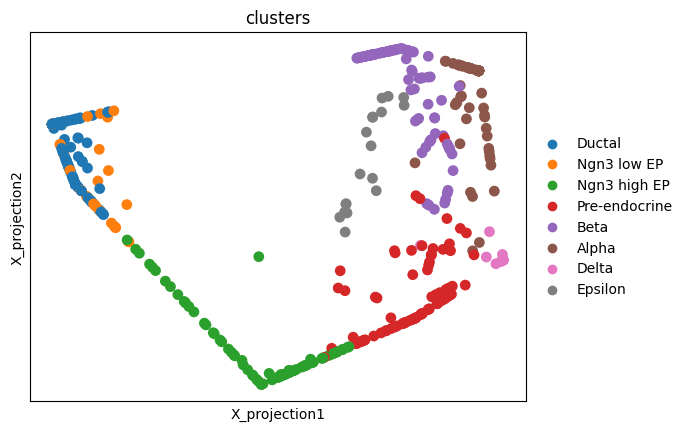

computing velocity embedding
    finished (0:00:00) --> added
    'velocity_projection', embedded velocity vectors (adata.obsm)


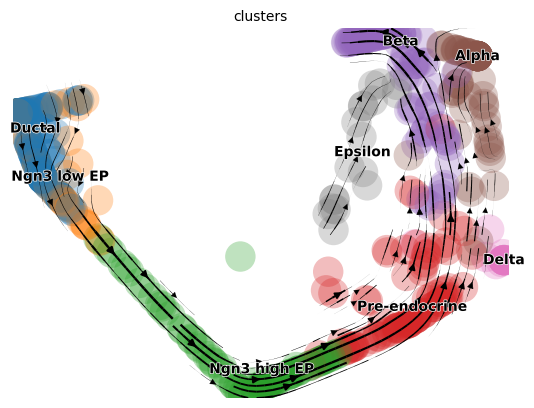

In [7]:
adata.obsm["X_projection"] = proj["x_proj"]
sc.pl.embedding(adata, basis="X_projection", color=cluster)
scv.pl.velocity_embedding_stream(adata, basis="X_projection")

TODO: 效果还不如PAGA, 后续结合PAGA与CBDir

In [15]:
# from cafe.metric import calculate_velocity_metrics

# calculate_velocity_metrics(adata, all_edges)

AttributeError: 'AnnData' object has no attribute 'prior_information'